In [1]:
#Importing libraries
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import ast
import seaborn as sns

#Loading data
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset['train'].to_pandas()

#Data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

d:\Anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Creating a custom job title list
# Filter dataframe according to the desired jobs
job_titles=['Data Analyst', 'Data Scientist', 'Data Engineer']
df_US = df[(df['job_title_short'].isin(job_titles)) & (df['job_country'] == 'United States')].copy()
df_US['job_title_short'].value_counts()

job_title_short
Data Analyst      67816
Data Scientist    58830
Data Engineer     35080
Name: count, dtype: int64

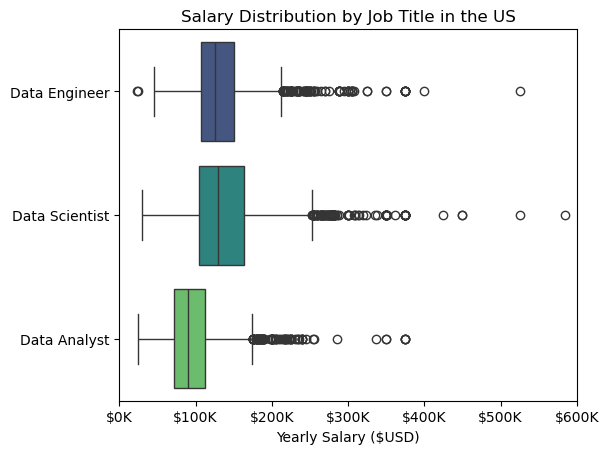

In [7]:
# Create the boxplot grouped by job title
# vert=False makes it horizontal, which is better for reading long category names
# df_US.boxplot(column='salary_year_avg', by='job_title_short', vert=False, figsize=(10, 6)) -- before seaborn
sns.boxplot(
    data=df_US, 
    x='salary_year_avg', 
    y='job_title_short', 
    hue='job_title_short',
    palette='viridis',     # Professional color gradient
    legend=False         # Hide legend since labels are on the Y-axis
)

# 'gca' stands for 'Get Current Axes' - allows us to modify the plot's properties
ax = plt.gca()

# Apply custom formatting to the X-axis using a lambda function
# This converts raw numbers (100000) to human-readable strings ($100K)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos : f'${int(x/1000)}K'))

# Clean up the titles: boxplot() adds a messy default 'suptitle' we want to remove
plt.title('Salary Distribution by Job Title in the US')
plt.suptitle('') 

# Final aesthetic adjustments
plt.tight_layout() # Optimizes spacing so labels don't get cut off
plt.ylabel('')      # Removes the redundant 'job_title_short' label on the Y-axis
plt.xlim(0, 600000) # Sets the salary range; helpful if you have extreme outliers
plt.grid(False)     # Removing gridlines makes the 'boxes' and 'whiskers' stand out more
plt.xlabel('Yearly Salary ($USD)')

plt.show()